# Research Questions

The goal of this notebook is to answer the research question, mentioned in `01_start` notebook. The questions are categorized between, consistency, volume/strength and correlation questions. 

The goal of the research question is to gain insight on workout data, and to give an advise based on the results. The plots can also be added to the dashboard that will be created with PowerBI.

In [100]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [101]:
df = pd.read_csv('cleaned_data.csv')

df['date'] = pd.to_datetime(df['date'])
df['date_short'] = pd.to_datetime(df['date_short'])

In [102]:
df.head()

,title,date,duration,exercise,weight,reps,set_type,date_short,body_weight,primary_muscle,secondary_muscle,volume,session_id
0,evening session,2026-03-29 19:33:12,01:55:18,full squat,80.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",640.0,271
1,evening session,2026-03-29 19:33:12,01:55:18,full squat,90.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",720.0,271
2,evening session,2026-03-29 19:33:12,01:55:18,full squat,90.0,8.0,normal_set,2026-03-29,69.6,quadriceps,"glutes, lower back",720.0,271
3,evening session,2026-03-29 19:33:12,01:55:18,lever seated leg press,120.0,6.0,normal_set,2026-03-29,69.6,quadriceps,glutes,720.0,271
4,evening session,2026-03-29 19:33:12,01:55:18,lever seated leg press,120.0,6.0,normal_set,2026-03-29,69.6,quadriceps,glutes,720.0,271


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4158 entries, 0 to 4157
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             4158 non-null   object        
 1   date              4158 non-null   datetime64[ns]
 2   duration          4158 non-null   object        
 3   exercise          4158 non-null   object        
 4   weight            4158 non-null   float64       
 5   reps              4158 non-null   float64       
 6   set_type          4158 non-null   object        
 7   date_short        4158 non-null   datetime64[ns]
 8   body_weight       4158 non-null   float64       
 9   primary_muscle    4158 non-null   object        
 10  secondary_muscle  4158 non-null   object        
 11  volume            4158 non-null   float64       
 12  session_id        4158 non-null   int64         
dtypes: datetime64[ns](2), float64(4), int64(1), object(6)
memory usage: 422.4+ KB


# Consistency 

### Questions

1. How often does the user train per week?
2. On which days does the user train the most?
3. How does the workout frequency change over time?
4. At what time does the user workout the most?

## 1. How often does the user train per week on average?



### Table

In [104]:
# total number of workouts

for y in range(2024, 2027):
	dft = df[pd.to_datetime(df["date"]).dt.year == y]
	count_workouts = dft.groupby('date').size().count()

	# Total amount of days
	total_days = max(dft['date_short']) - min(dft['date_short'])
	# total amount of week
	total_weeks = total_days.days / 7
	
	# average amount of workouts per week
	average_workouts_per_week = count_workouts / total_weeks

	print(f" The user trains {average_workouts_per_week.round(1)} times per week on average in {y}.")

 The user trains 3.2 times per week on average in 2024.
 The user trains 3.3 times per week on average in 2025.
 The user trains 3.5 times per week on average in 2026.


In [105]:
df.groupby(df['date_short'].dt.to_period('M'))['session_id'].nunique()



date_short
2024-08     4
2024-09    15
2024-10    12
2024-11    13
2024-12    12
2025-01     9
2025-02    14
2025-03    14
2025-04    15
2025-05    20
2025-06    14
2025-07    21
2025-08     5
2025-09    16
2025-10    15
2025-11    18
2025-12    12
2026-01    11
2026-02    17
2026-03    15
Freq: M, Name: session_id, dtype: int64

In [106]:
weekly = (
    df.groupby(pd.Grouper(key="date", freq="W"))["session_id"]
    .nunique()
    .rename("workouts")
)
weekly = weekly.reset_index()
weekly.head()

,date,workouts
0,2024-09-01,4
1,2024-09-08,4
2,2024-09-15,3
3,2024-09-22,4
4,2024-09-29,3


In [107]:
monthly = (
    weekly.groupby(pd.Grouper(key='date', freq="ME"))["workouts"]
	.mean()
	.round(0)
	.rename('workouts')
)

monthly = monthly.reset_index()

### Plot

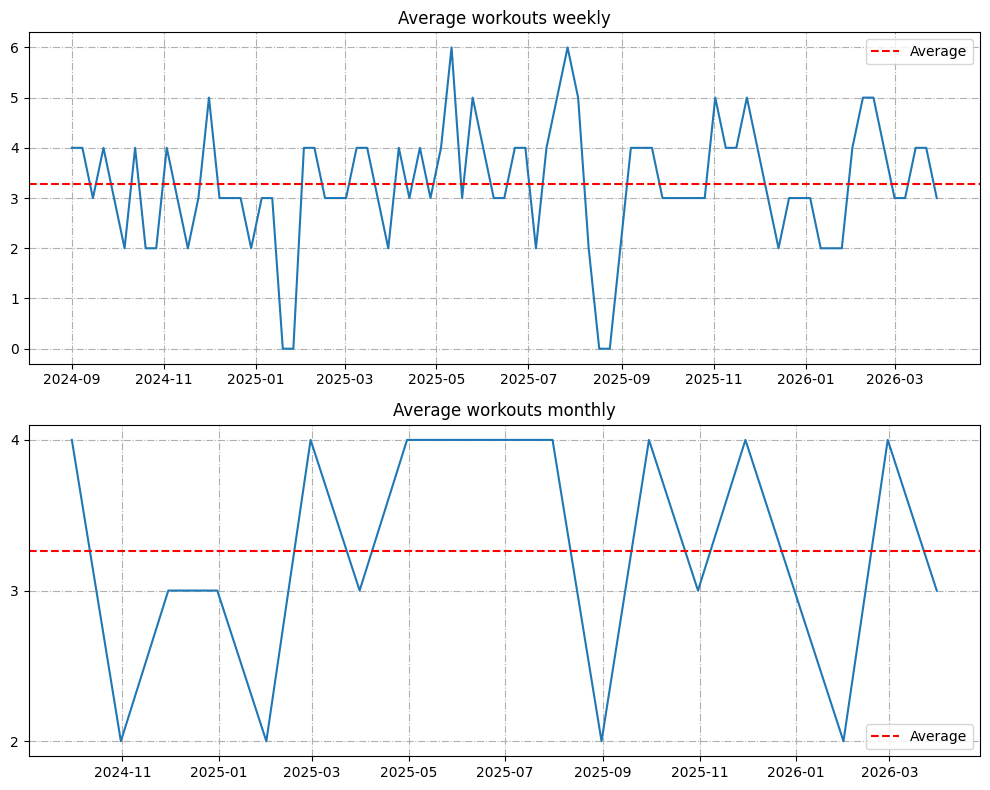

In [108]:
# create the plots in columns



fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(weekly['date'], weekly['workouts'])
ax[0].set_title("Average workouts weekly")
ax[0].set_yticks(range(weekly['workouts'].min().astype(int) , weekly['workouts'].max().astype(int)+1))
ax[0].grid(True, linestyle="dashdot")
ax[0].axhline(y=weekly['workouts'].mean(), color="red", label="Average", linestyle="dashed")
ax[0].legend()

ax[1].plot(monthly['date'], monthly['workouts'])
ax[1].set_title("Average workouts monthly")
ax[1].set_yticks(range(monthly['workouts'].min().astype(int) , monthly['workouts'].max().astype(int)+1))
ax[1].grid(True, linestyle="dashdot")
ax[1].axhline(y=monthly['workouts'].mean(), color="red", label="Average", linestyle="dashed")
ax[1].legend()

plt.tight_layout()
plt.show()



### Conclusion

Based on the graph the user train on average 3 times a week. The monthly graph shows that the user swings a lot between 4 and 2 times a week. In the weekly graph we can see more clearly which periods the user trains more or less. 

On the weekly graph we can see that the user trains less in the summer vacation, this can be because the user is on vacation and does not have access to a gym, or because the user is doing more outdoor activities.
There is also a gap in the first month of the year, this can have a variety of reasons, but it is likely that the user is taking a break after the holiday season.

## 2. On which days does the user train the most?

### Table

In [109]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


weekday_2024 = (
	df.assign(weekday=df["date"].dt.day_name())[df['date_short'].dt.year == 2024]
	.groupby('weekday')['session_id']
	.nunique()
	.reindex(order, fill_value=0)
	.rename("workouts")
	)

weekday_2024 = weekday_2024.reset_index()

weekday_2025 = (
	df.assign(weekday=df["date"].dt.day_name())[df['date_short'].dt.year == 2025]
	.groupby('weekday')['session_id']
	.nunique()
	.reindex(order, fill_value=0)
	.rename("workouts")
	)

weekday_2025 = weekday_2025.reset_index()

weekday_2026 = (
	df.assign(weekday=df["date"].dt.day_name())[df['date_short'].dt.year == 2026]
	.groupby('weekday')['session_id']
	.nunique()
	.reindex(order, fill_value=0)
	.rename("workouts")
	)

weekday_2026 = weekday_2026.reset_index()
weekday_2026


,weekday,workouts
0,Monday,6
1,Tuesday,6
2,Wednesday,3
3,Thursday,8
4,Friday,7
5,Saturday,2
6,Sunday,11


### Plot

In [110]:
week_colors = [
    '#e63946', # Monday (Red)
    '#f4a261', # Tuesday (Sand)
    '#e9c46a', # Wednesday (Yellow)
    '#2a9d8f', # Thursday (Teal)
    '#264653', # Friday (Charcoal)
    '#457b9d', # Saturday (Steel Blue)
    '#1d3557'  # Sunday (Navy)
]

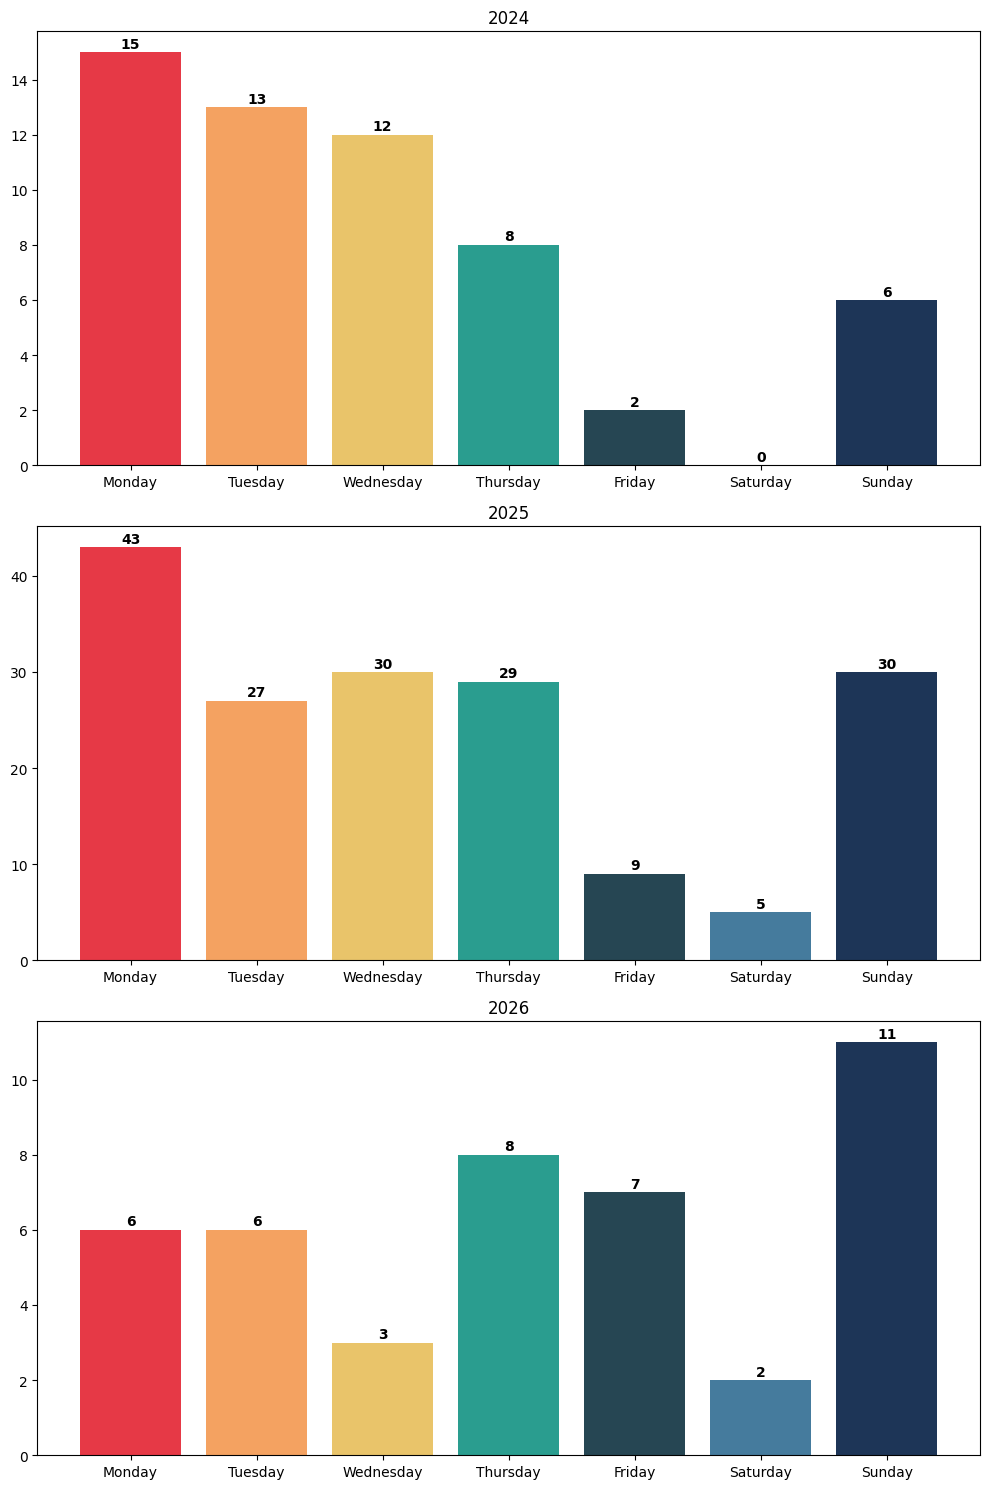

In [111]:
by_year = {2024: weekday_2024, 2025: weekday_2025, 2026: weekday_2026}

fig, axes = plt.subplots(3, 1, figsize=(10, 15))  

for i, year in enumerate(range(2024, 2027)):
    w = by_year[year]
    ax = axes[i]
    bars = ax.bar(x=w["weekday"], height=w["workouts"], color=week_colors)
    ax.bar_label(bars, padding=1, fontweight="bold")
    ax.set_title(str(year))

plt.tight_layout()


### Conclusion

Based on the graph, the user trains in 2024 the first 3 days of the year the most. This changes in 2025 and 2026, where the user trains more on sunday, wednesday and thursday. This can be because the user has more time to train on those days, or because the user tries to avoid training when it is busy.

## 3. How does the workout frequency change over time?

### Table

In [112]:
weekly.head()

weekly1 = weekly.assign(cum_mean=weekly["workouts"].expanding().mean().round(1))
# Add this line before plotting
weekly1['moving_avg'] = weekly1['workouts'].rolling(window=8, min_periods=1).mean()
weekly1.head()

,date,workouts,cum_mean,moving_avg
0,2024-09-01,4,4.0,4.000000
1,2024-09-08,4,4.0,4.000000
2,2024-09-15,3,3.7,3.666667
3,2024-09-22,4,3.8,3.750000
4,2024-09-29,3,3.6,3.600000


### Plot

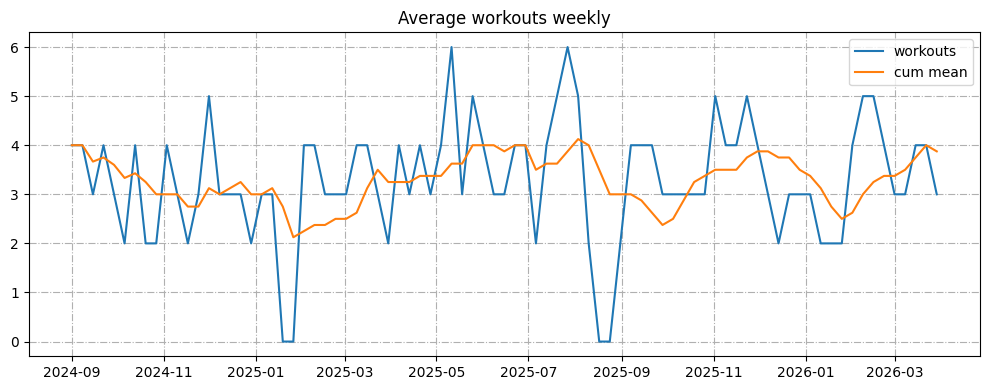

In [113]:
# create the plots in columns



fig, ax = plt.subplots( figsize=(10, 4))

ax.plot(weekly1['date'], weekly1[['workouts']], label="workouts")
ax.plot(weekly1['date'], weekly1[['moving_avg']], label="cum mean")
ax.set_title("Average workouts weekly")
ax.set_yticks(range(weekly1['workouts'].min().astype(int) , weekly1['workouts'].max().astype(int)+1))
ax.grid(True, linestyle="dashdot")
ax.legend()



plt.tight_layout()
plt.show()



### Conclusion

The graph shows that the user sometimes train 5/6 times a week, but also 2 times a week. But the average is around 3/4 times a week. This shows that the user is consistent in training, but also has some weeks where they train less. 

## 4. At what time does the user workout the most?

### Table


In [114]:
from os import access


starts = (
    df.groupby("session_id", as_index=False)["date"]
    .min()
    .rename(columns={"date": "session_start"})
)

starts["hour"] = starts["session_start"].dt.hour

by_hour = (
    starts.groupby("hour", as_index=False)
    .size()
    .rename(columns={"size": "sessions"})
    .sort_values("sessions", ascending=False)
	.sort_index()
)

by_hour

,hour,sessions
0,9,2
1,10,4
2,11,7
3,12,1
4,13,7
5,14,11
6,15,16
7,16,9
8,17,10
9,18,26


### Plot

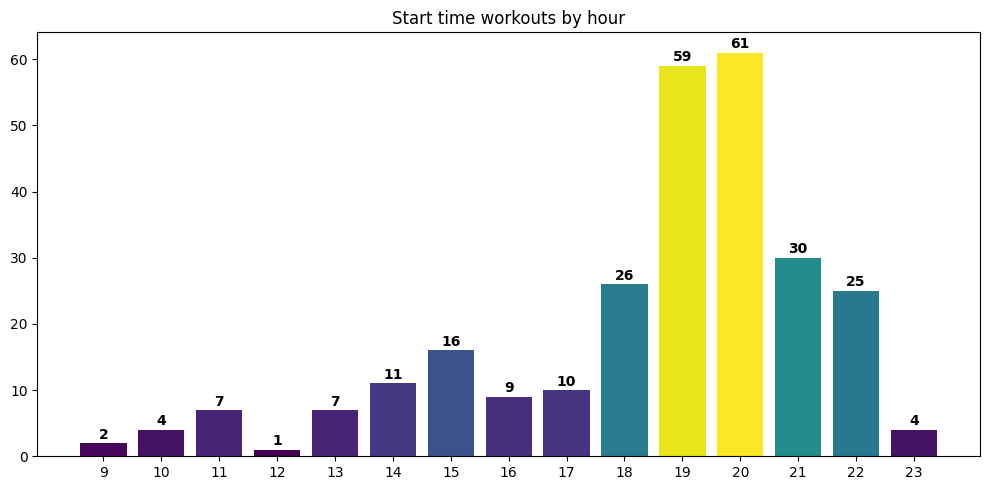

In [115]:
from matplotlib import cm

counts = by_hour['sessions']
norm = plt.Normalize(counts.min(), counts.max())
colors = cm.viridis(norm(counts))

fig, ax = plt.subplots(figsize=(10, 5))  

bars = ax.bar(x=by_hour['hour'], height=by_hour['sessions'], color=colors)
ax.bar_label(bars, padding=1, fontweight="bold")
ax.set_title("Start time workouts by hour")
ax.set_xticks(np.arange(by_hour['hour'].min(), by_hour['hour'].max() + 1, 1))

plt.tight_layout()
plt.show()

### Conclusion

Based ont the graph, the user train the most between 18:00 and 21:00. This can be because the user has more time to train after work, or because the user prefers to train in the evening. The user doesn't train a lot in the morning and afternoon, this can be because the user is busy with work or other activities.

---


# Volume and Strength


## Questions

5. Growth of primary and secondary muscle group(volume/weight)?
6. Does the volume and strength increase over time?
7. Are there any plateaus in the progress (weight)?

## 5. Growth of primary and secondary muscle group?

Growth of primary and secondary muscle group(volume/weight)?

### Table

In [116]:
df.columns

Index(['title', 'date', 'duration', 'exercise', 'weight', 'reps', 'set_type',
       'date_short', 'body_weight', 'primary_muscle', 'secondary_muscle',
       'volume', 'session_id'],
      dtype='object')

In [117]:
growth_muscle_group_prim = (

	df[['session_id','date_short','exercise','weight','volume','primary_muscle','secondary_muscle']]
	.groupby(["date_short","primary_muscle"], as_index=False)['volume']
	.sum()
	# .value_counts()
	
)
mgp = growth_muscle_group_prim
mgp





,date_short,primary_muscle,volume
0,2024-08-26,biceps,724.0
1,2024-08-26,chest,2116.0
2,2024-08-26,lats,1560.0
3,2024-08-26,quadriceps,2010.0
4,2024-08-26,triceps,600.0
...,...,...,...
935,2026-03-29,calves,2632.0
936,2026-03-29,hamstrings,1920.0
937,2026-03-29,quadriceps,4240.0
938,2026-03-29,shoulders,0.0


### Plot

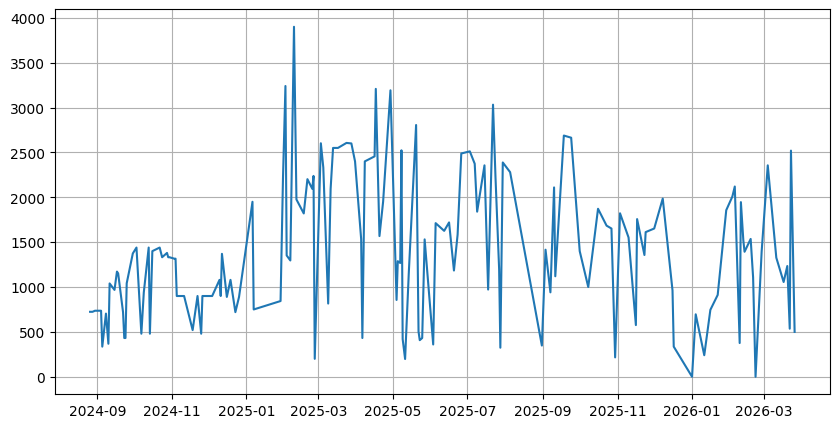

In [118]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(mgp['date_short'][mgp['primary_muscle'] == 'biceps'], mgp['volume'][mgp['primary_muscle'] == 'biceps'])
ax.grid()

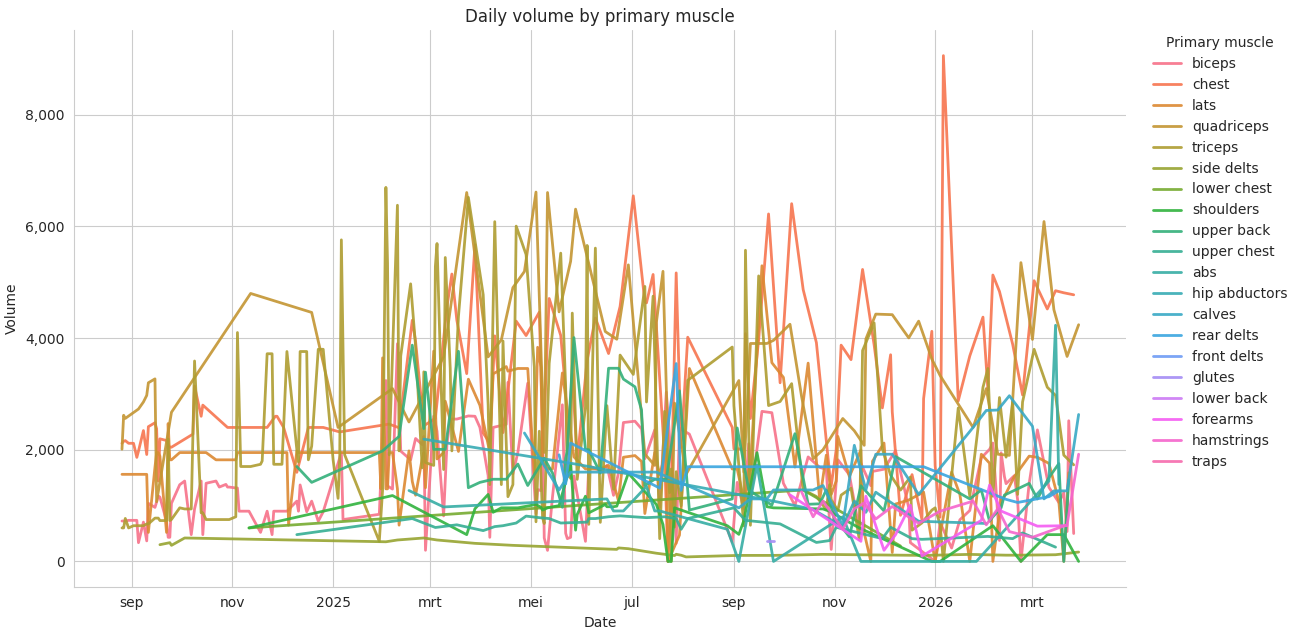

In [119]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plot_df = mgp.sort_values(["date_short", "primary_muscle"])
n_muscles = int(plot_df["primary_muscle"].nunique())

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(13, 6.5))
    sns.lineplot(
        data=plot_df,
        x="date_short",
        y="volume",
        hue="primary_muscle",
        errorbar=None,
        ax=ax,
        palette=sns.color_palette("husl", n_colors=max(n_muscles, 3)),
        linewidth=2,
        alpha=0.9,
    )
    sns.despine()

    ax.set_xlabel("Date")
    ax.set_ylabel("Volume")
    ax.set_title("Daily volume by primary muscle")

    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    sns.move_legend(
        ax,
        "upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
        frameon=False,
        title="Primary muscle",
    )

    fig.tight_layout()

plt.show()

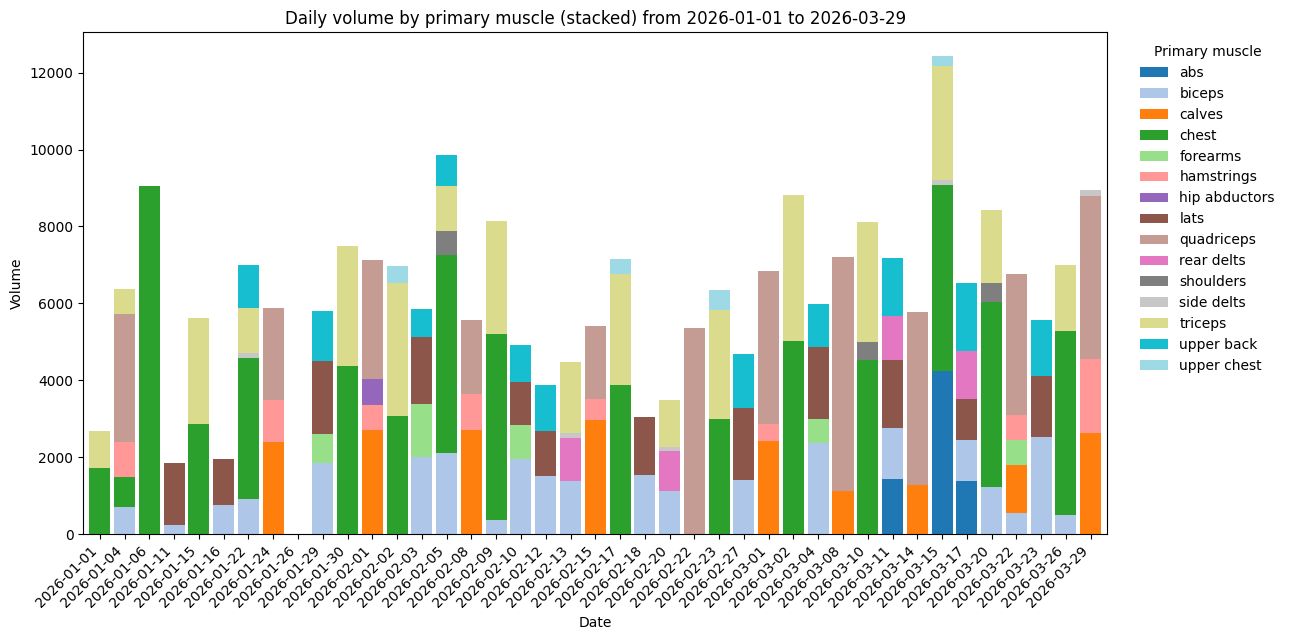

In [120]:
stacked = (
    plot_df[plot_df['date_short'].dt.year == 2026]
    .pivot(index="date_short", columns="primary_muscle", values="volume")
    .fillna(0)
    .sort_index()
)

ax = stacked.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6.5),
    width=0.85,
    colormap="tab20",  # or pass color= list of len(columns)
)
ax.set_xlabel("Date")
ax.set_ylabel("Volume")
min_date = plot_df['date_short'][plot_df['date_short'].dt.year == 2026].min()
max_date = plot_df['date_short'][plot_df['date_short'].dt.year == 2026].max()

min_date = min_date.strftime("%Y-%m-%d")
max_date = max_date.strftime("%Y-%m-%d")

ax.set_title(f"Daily volume by primary muscle (stacked) from {min_date} to {max_date}")

ax.set_xticks(range(len(stacked)))
ax.set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in stacked.index],
    rotation=45,
    ha="right",
)

plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.legend(title="Primary muscle", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



### Conclusion

The first graph shows how to volume of each muscle group changes over time. The graph is to chaotic to gain insights from it, even after reducing the graph to one muscle group, the graph is still highly volatile.

I create a second graph to show the volume of each muscle group in a stacked bar chart, this gave me a more detailed overview of the muscle group trained with each workout. This graph shows data from 2026 and the relative volume for each muscle. 

One of the insights is that when the user trains `quadriceps` that it is a big portion of the workout in combination with other leg muscle. This shows the user might need to focus on calves and hamstring more to make sure that the legs muscles are balanced. 

The small bars in the chart can be a sign that the user might need to increase the volume of other muscle.


## 6. Does the volume and strength increase over time of a workout?

### Table

In [121]:
egp = (
df[['session_id','date_short','exercise','weight','volume','primary_muscle','secondary_muscle']]
.groupby(["date_short", "exercise", "primary_muscle"], as_index=False)
['weight'].max()

)
# egp.groupby(["date_short", "exercise"], as_index=False)["weight"].max()[egp['exercise'] == "bench press"]
egp[egp['primary_muscle'] == 'biceps']

# egp[egp['primary_muscle'] == 'biceps']['exercise'].nunique()

# volume
egp1 = (
df[['session_id','date_short','exercise','weight','volume','primary_muscle','secondary_muscle']]
.groupby(["date_short", "exercise", "primary_muscle"], as_index=False)
['volume'].max()

)


In [122]:
egp['primary_muscle'].unique()

array(['biceps', 'chest', 'quadriceps', 'lats', 'triceps', 'side delts',
       'lower chest', 'shoulders', 'upper chest', 'upper back', 'abs',
       'hip abductors', 'calves', 'rear delts', 'front delts', 'glutes',
       'lower back', 'forearms', 'hamstrings', 'traps'], dtype=object)

### Plot


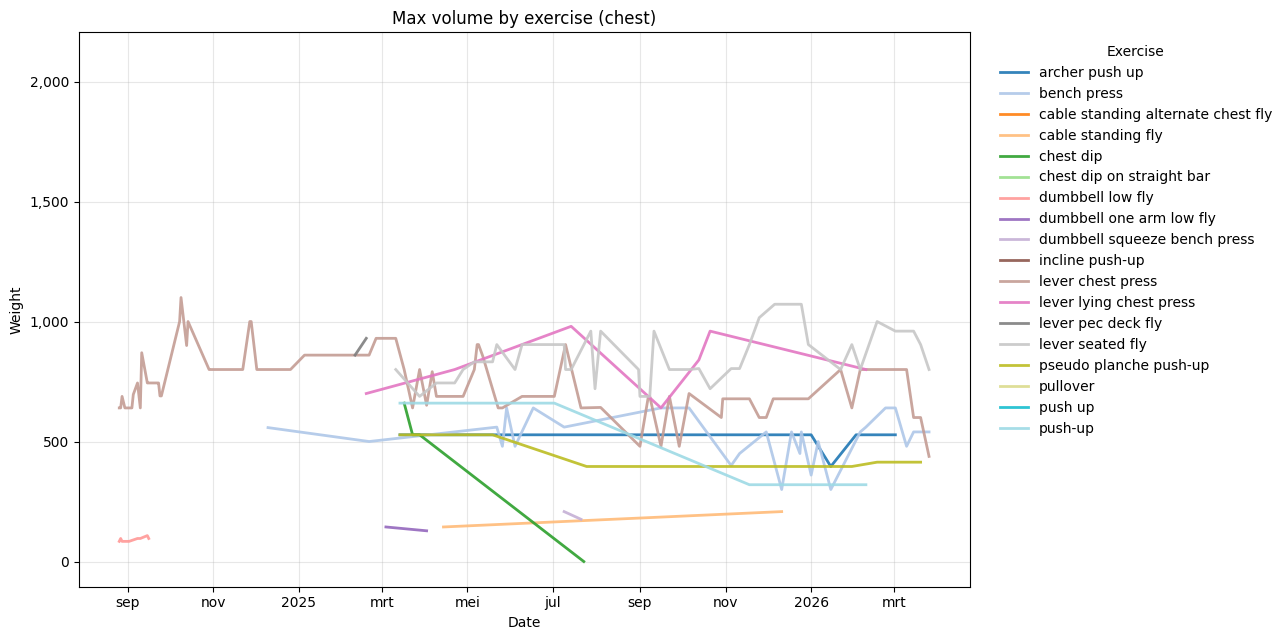

In [123]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df_e = egp1[egp1["primary_muscle"] == "chest"].sort_values(["exercise", "date_short"])
exercises = df_e["exercise"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, max(len(exercises), 1)))

fig, ax = plt.subplots(figsize=(13, 6.5))

for ex, color in zip(exercises, colors):
    sub = df_e[df_e["exercise"] == ex]
    ax.plot(
        sub["date_short"],
        sub["volume"],
        label=ex,
        color=color,
        linewidth=2,
        alpha=0.9,
    )

ax.set_xlabel("Date")
ax.set_ylabel("Weight")
ax.set_title("Max volume by exercise (chest)")

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

ax.legend(title="Exercise", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

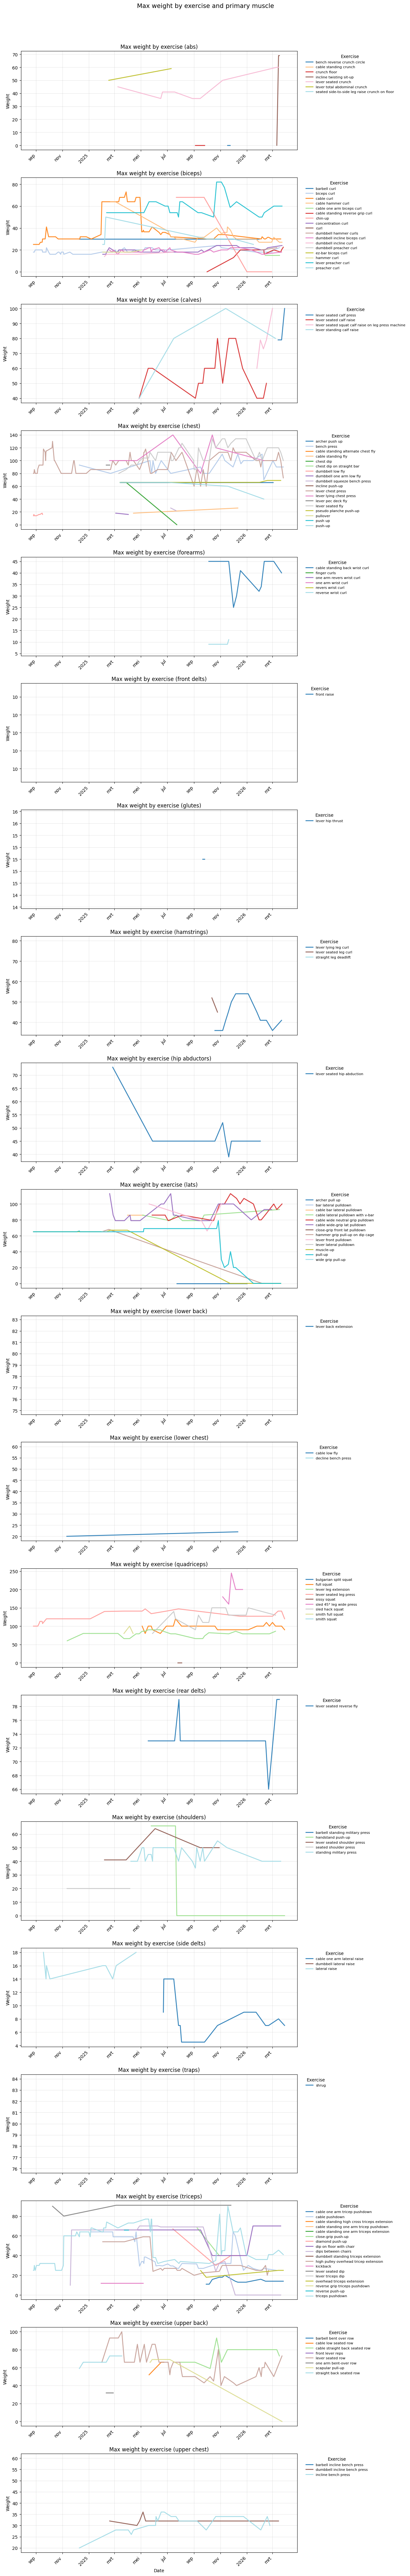

In [124]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

muscles = sorted(egp["primary_muscle"].dropna().unique())
n_muscles = len(muscles)

fig, axes = plt.subplots(
    nrows=n_muscles,
    ncols=1,
    figsize=(13, 4 * n_muscles),  # ~4" per row; tweak as needed
    sharex=True,
    squeeze=False,
)

locator = mdates.AutoDateLocator()
date_fmt = mdates.ConciseDateFormatter(locator)

for ax, muscle in zip(axes.flat, muscles):
    df_e = egp[egp["primary_muscle"] == muscle].sort_values(["exercise", "date_short"])
    exercises = df_e["exercise"].unique()
	

    ax.tick_params(axis="x", labelbottom=True, rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

    if len(exercises) == 0:
        ax.set_visible(False)
        continue

    colors = plt.cm.tab20(np.linspace(0, 1, max(len(exercises), 1)))

    for ex, color in zip(exercises, colors):
        sub = df_e[df_e["exercise"] == ex]
        ax.plot(
            sub["date_short"],
            sub["weight"],
            label=ex,
            color=color,
            linewidth=2,
            alpha=0.9,
        )

    ax.set_ylabel("Weight")
    ax.set_title(f"Max weight by exercise ({muscle})")
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(date_fmt)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Exercise", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)

# x-label only on bottom subplot (sharex)
axes.flat[-1].set_xlabel("Date")

fig.suptitle("Max weight by exercise and primary muscle", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

### Conclusion

Based on the graph, the user doesn't show a lot of improvement in terms of max weight over time. Even though some exercises, such as pec fly's and bench press, did increase over time most of the exercise didn't increase a lot over time. 

The exercise which dropped to 0 are usually body weight exercise so that value can be filled with the body weight at that time, but most exercises didn't increase. This can happen because the muscles of the user are sore or overtrained, there can also be other factors.

In order to increase this the max weight of each exercise is to apply progressive overload, this can be increase of weight or reps. 

---

# Correlation Questions

## Questions

7.  Does the user perform better at certain times of the day?
8.  Does the user perform better on certain days of the week?

## 7. Does the user perform better at certain times of the day?

will be shown in volume

### Table


In [125]:
# show total volume each date
t_vol = (df[['date', 'volume']]
		.groupby(['date'])['volume']
		.sum()
		.rename("total_volume")
		.reset_index()
		)

# add colums with the start hour of the workout
t_vol['hour'] = t_vol['date'].dt.hour

t_vol

,date,total_volume,hour
0,2024-08-26 18:34:02,7010.0,18
1,2024-08-27 10:29:00,7654.0,10
2,2024-08-28 20:33:56,7780.0,20
3,2024-08-30 13:42:27,5012.0,13
4,2024-09-02 22:46:12,5052.0,22
...,...,...,...
267,2026-03-20 19:25:55,8430.0,19
268,2026-03-22 19:27:22,6768.0,19
269,2026-03-23 18:15:20,5572.0,18
270,2026-03-26 20:31:52,7006.0,20


In [126]:
# average workout volume of each hour of the day
t_vol = t_vol.groupby('hour', as_index=False)['total_volume'].mean()



In [127]:
print(type(t_vol))

<class 'pandas.core.frame.DataFrame'>


### Plot

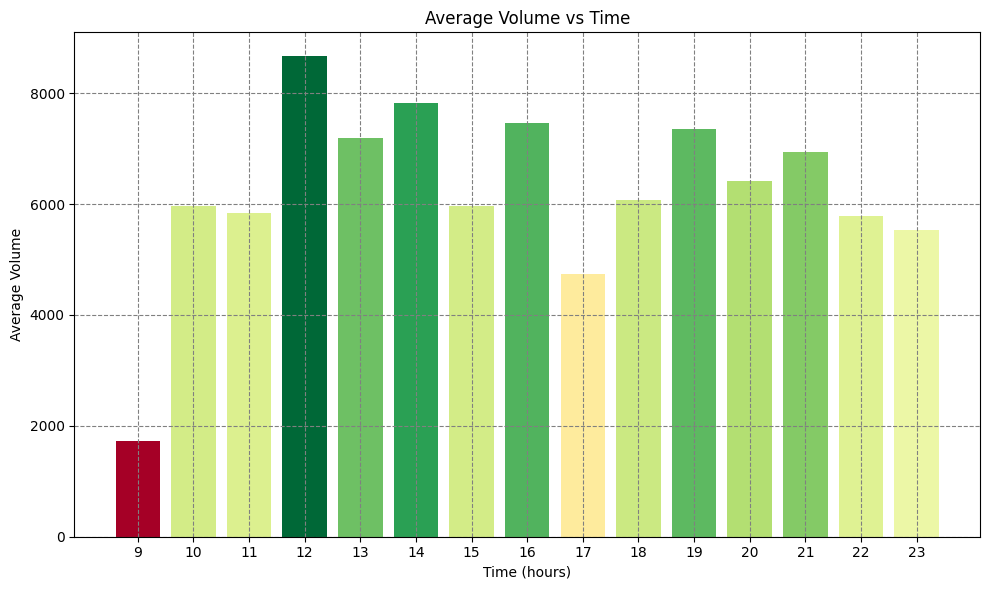

In [128]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

# 1. Extract values
volumes = t_vol['total_volume'].values

# 2. Normalize the data strictly between 0 and 1
# This ensures the min value maps to 0.0 and the max value maps to 1.0
norm = plt.Normalize(vmin=volumes.min(), vmax=volumes.max())

# 3. Use a Red-Yellow-Green colormap (or 'YlOrBr' / custom profiles)
# For Orange-to-Green, 'RdYlGn' gives a beautiful transition.
cmap = plt.colormaps['RdYlGn']
colors = cmap(norm(volumes))

# 4. Plot using the dynamically scaled colors
ax.bar(t_vol['hour'], t_vol['total_volume'], color=colors)

ax.set_ylabel('Average Volume')
ax.set_xlabel('Time (hours)')
ax.set_title('Average Volume vs Time')
ax.grid(color="grey", linestyle='--')
ax.set_xticks(t_vol['hour'])

fig.tight_layout()
plt.show()

### Conclusion

Based on the graph, the user trains with higher volume in the afternoon. This can be a correlation with energy, time and motivation. 

> The user may have more time in the afternoon and train more that results in a higher volume. 
> The user may also have more energy in the afternoon, which can lead to a higher volume. 
> The user may also be more motivated to train in the afternoon, which can lead to a higher volume.

## 8.Does the user perform better on certain days of the week?

### Table

In [161]:
# show total volume each date
d_vol = (df[['date', 'volume']]
		.groupby(['date'])['volume']
		.sum()
		.rename("total_volume")
		.reset_index()
		)

# add colums with the day of the week

d_vol['day'] = d_vol['date'].dt.day_name()
d_vol.info()

d_vol = d_vol.groupby('day', as_index=True)['total_volume'].mean().round(0).reindex(order)

d_vol = d_vol.reset_index()

# d_vol = d_vol.rename(columns={'index': 'Day_of_Week'})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          272 non-null    datetime64[ns]
 1   total_volume  272 non-null    float64       
 2   day           272 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 6.5+ KB


In [162]:
d_vol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   day           7 non-null      object 
 1   total_volume  7 non-null      float64
dtypes: float64(1), object(1)
memory usage: 244.0+ bytes


### Plot

In [163]:
d_vol.head()

,day,total_volume
0,Monday,6568.0
1,Tuesday,7336.0
2,Wednesday,6295.0
3,Thursday,6018.0
4,Friday,5663.0


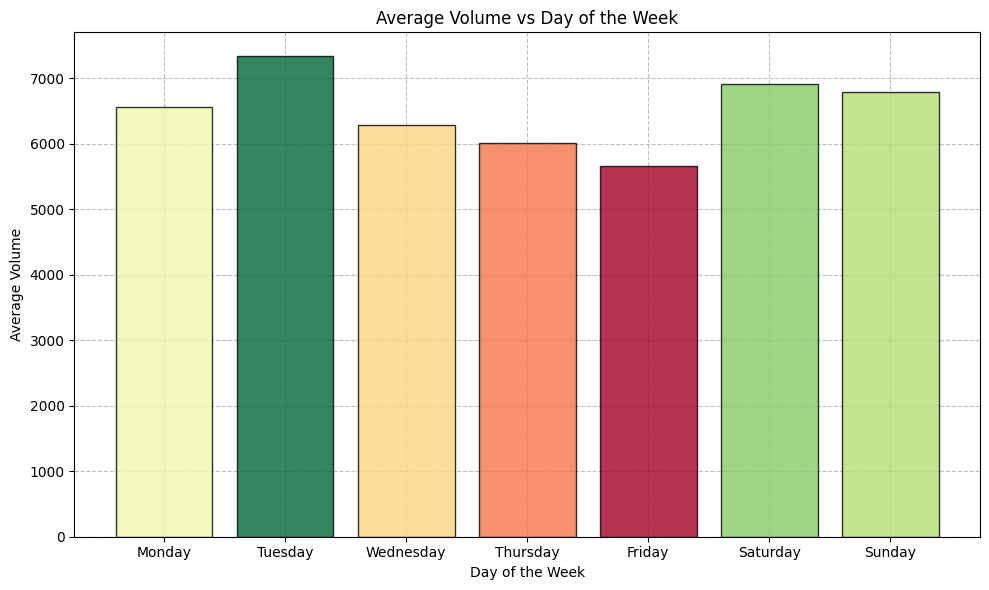

In [166]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

# 1. Grab the column directly (pandas Series work perfectly with matplotlib)
volumes = d_vol['total_volume']

# 2. Normalize the data strictly between 0 and 1
# This ensures the min value maps to 0.0 and the max value maps to 1.0
norm = plt.Normalize(vmin=volumes.min(), vmax=volumes.max())

# 3. Use a Red-Yellow-Green colormap
cmap = plt.colormaps['RdYlGn']
colors = cmap(norm(volumes))

# 4. Plot using the dynamically scaled colors
ax.bar(d_vol['day'], d_vol['total_volume'], color=colors, edgecolor='black', alpha=0.8)

ax.set_ylabel('Average Volume')
ax.set_xlabel('Day of the Week')
ax.set_title('Average Volume vs Day of the Week')

# Setting up the grid below the bars for a cleaner look
ax.grid(color="grey", linestyle='--', alpha=0.5)
ax.set_axisbelow(True) 

ax.set_xticks(range(len(d_vol['day'])))
ax.set_xticklabels(d_vol['day'])

fig.tight_layout()
plt.show()

### Conclusion

Based on the graph, the user trains with higher volume on tuesday and saterday. This can have a correlation with the type of exercise the user does on those days, but the difference between the days is not that big, so it can also be a correlation with the time of the day, energy and motivation.